# Assignment 5: Transfer Learning for Text Classification
**Objective:** Fine-tune a pre-trained Transformer (DistilBERT) for Sentiment Analysis (Negative, Neutral, Positive).
**Hardware:** GPU Enabled

In [1]:
# Environment Setup and Data Loading
!pip install -q transformers datasets evaluate accelerate kagglehub

import pandas as pd
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

# Download dataset programmatically
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
csv_file = os.path.join(path, "train.csv")

df = pd.read_csv(csv_file, encoding='latin-1')
df = df[['text', 'sentiment']].dropna()

# Map sentiments
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].str.strip().str.lower().map(sentiment_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Taking a larger sample since we have a GPU
df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Dataset ready. Total instances: {len(df_sample)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.
Dataset ready. Total instances: 5000


### Tokenization & Dataset Preparation
Converting text to tokens using DistilBERT's tokenizer and creating Hugging Face `Dataset` objects.

In [2]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

train_df, test_df = train_test_split(df_sample, test_size=0.2, random_state=42, stratify=df_sample['label'])

hf_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df).remove_columns(["__index_level_0__"]),
    'test': Dataset.from_pandas(test_df).remove_columns(["__index_level_0__"])
})

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)
print("Tokenization complete.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization complete.


### Model Fine-Tuning
Using Hugging Face's `Trainer` API to fine-tune DistilBERT for 5 epochs.

In [3]:
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return metric.compute(predictions=np.argmax(logits, axis=-1), references=labels)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label={0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"},
    label2id={"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5, # Increased epochs
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Starting Fine-tuning...")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.663223,0.565745,0.780000
2,0.480573,0.544946,0.795000
3,0.329688,0.581032,0.798000
4,0.243888,0.665287,0.787000
5,0.194115,0.697378,0.789000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1250, training_loss=0.4044470336914063, metrics={'train_runtime': 270.3106, 'train_samples_per_second': 73.989, 'train_steps_per_second': 4.624, 'total_flos': 662348805120000.0, 'train_loss': 0.4044470336914063, 'epoch': 5.0})

### Evaluation
Generating the classification report and visualizing model performance via a Confusion Matrix.

Final Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.78      0.79       288
     Neutral       0.77      0.77      0.77       408
    Positive       0.82      0.85      0.83       304

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.79      0.80      0.79      1000



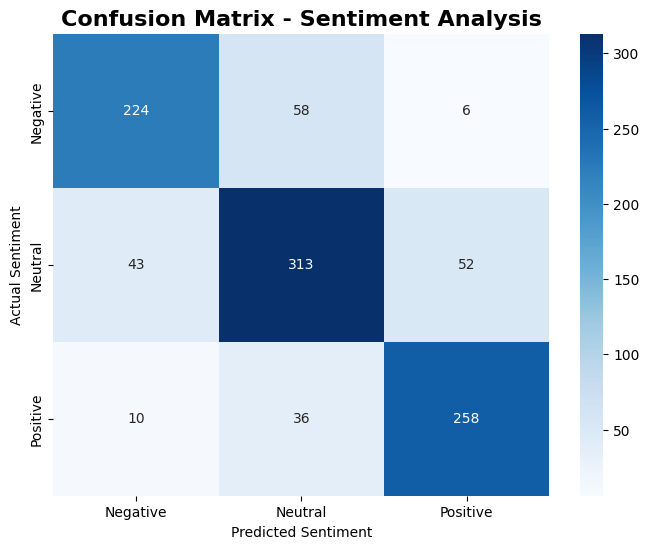

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids
target_names = ["Negative", "Neutral", "Positive"]

print("Final Classification Report:")
print(classification_report(labels, preds, target_names=target_names))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Sentiment Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()